# Adaptive MACD + Bollinger Strategy (BTC & ETH)

Strategy definitions:
- `MACD`: a trend-following long/flat rule based on the MACD line crossing its signal line
- `Bollinger Bands`: a symmetric mean-reversion rule that buys below the lower band, sells above the upper band, and exits at the rolling mean
- `Adaptive switching`: uses MACD in `TREND` regimes and Bollinger in `MEAN_REVERSION` regimes

### Section 1: Data Cleaning and Manipulation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


In [2]:
eth_macd=pd.read_csv('eth_macd_18_50_13_post_trade_table.csv',parse_dates=True,index_col=0)
btc_macd=pd.read_csv('btc_macd_16_20_15_post_trade_table.csv',parse_dates=True,index_col=0)

eth_macd.rename(columns={
    'trade': 'macd_trade',
    'position': 'macd_position',
    'trade_action': 'macd_trade_action'
}, inplace=True)

btc_macd.rename(columns={
    'trade': 'macd_trade',
    'position': 'macd_position',
    'trade_action': 'macd_trade_action'
}, inplace=True)

eth_macd.head(), btc_macd.head()

(                 price  log_return  macd_trade macd_trade_action  macd_position
 date                                                                           
 2018-01-01  772.640991    0.000000           0              hold              0
 2018-01-02  884.443970    0.135145           0              hold              0
 2018-01-03  962.719971    0.084803           1               buy              1
 2018-01-04  980.921997    0.018730           0              hold              1
 2018-01-05  997.719971    0.016980           0              hold              1,
                    price  log_return  macd_trade macd_trade_action  macd_position
 date                                                                             
 2018-01-01  13657.200195    0.000000           0              hold              0
 2018-01-02  14982.099609    0.092589           0              hold              0
 2018-01-03  15201.000000    0.014505           1               buy              1
 2018-01-04  1559

In [3]:
eth_bollinger=pd.read_csv('eth_bollinger_post_trade_table.csv',parse_dates=True,index_col=0)
btc_bollinger=pd.read_csv('btc_bollinger_post_trade_table.csv',parse_dates=True,index_col=0)

eth_bollinger.rename(columns={
    'trade': 'bollinger_trade',
    'position': 'bollinger_position',
    'trade_action': 'bollinger_trade_action'
}, inplace=True)

btc_bollinger.rename(columns={
    'trade': 'bollinger_trade',
    'position': 'bollinger_position',
    'trade_action': 'bollinger_trade_action'
}, inplace=True)

eth_bollinger.head(), btc_bollinger.head()

(               price  log_return  bollinger_trade bollinger_trade_action  bollinger_position
 date                                                                                        
 1/1/2018  772.640991    0.000000                0                   hold                   0
 2/1/2018  884.443970    0.135145                0                   hold                   0
 3/1/2018  962.719971    0.084803                0                   hold                   0
 4/1/2018  980.921997    0.018730                0                   hold                   0
 5/1/2018  997.719971    0.016980                0                   hold                   0,
                 price  log_return  bollinger_trade bollinger_trade_action  bollinger_position
 date                                                                                         
 1/1/2018  13657.20020    0.000000                0                   hold                   0
 2/1/2018  14982.09961    0.092589                0     

In [4]:
# Ensure both indices are datetime
eth_bollinger.index = pd.to_datetime(eth_bollinger.index, format='mixed', dayfirst=True)
btc_bollinger.index = pd.to_datetime(btc_bollinger.index, format='mixed', dayfirst=True)
eth_macd.index = pd.to_datetime(eth_macd.index)
btc_macd.index = pd.to_datetime(btc_macd.index)

# sort index just to be safe
eth_bollinger = eth_bollinger.sort_index()
eth_macd = eth_macd.sort_index()

btc_bollinger = btc_bollinger.sort_index()
btc_macd = btc_macd.sort_index()

# Join (ETH with ETH, BTC with BTC)
eth_combined = eth_bollinger.join(
    eth_macd.drop(columns=['price', 'log_return']),
    how='inner'
)

btc_combined = btc_bollinger.join(
    btc_macd.drop(columns=['price', 'log_return']),
    how='inner'
)

# View
eth_combined.head(), btc_combined.head()

(                 price  log_return  bollinger_trade bollinger_trade_action  bollinger_position  macd_trade macd_trade_action  \
 date                                                                                                                           
 2018-01-01  772.640991    0.000000                0                   hold                   0           0              hold   
 2018-01-02  884.443970    0.135145                0                   hold                   0           0              hold   
 2018-01-03  962.719971    0.084803                0                   hold                   0           1               buy   
 2018-01-04  980.921997    0.018730                0                   hold                   0           0              hold   
 2018-01-05  997.719971    0.016980                0                   hold                   0           0              hold   
 
             macd_position  
 date                       
 2018-01-01              0  
 2018-01

### Section 2: Trend Strength & Regime Switching

We define trend strength using a signed efficiency-ratio style measure:

$$
TS_t =
\frac{P_t - P_{t-L}}
{\sum_{i=t-L+1}^{t} \left| P_i - P_{i-1} \right|}
$$

The adaptive strategy switches regimes based on trend strength:

$$
\text{Position}_t =
\begin{cases}
\text{MACD}_t, & \text{if } TS_t > \tau \\
\text{Bollinger}_t, & \text{otherwise}
\end{cases}
$$

**where:**
- $P_t$ = price at time $t$
- $L$ = lookback window (e.g. 30)
- $\tau$ = threshold

**interpretation:**
- numerator → net directional move  
- denominator → total path length (volatility)  
- $|TS_t| \approx 1$ → strong trend  
- $TS_t \approx 0$ → choppy / mean-reverting  


In [5]:
# =========================
# Trend Strength + Adaptive Strategy
# =========================

# Parameters
L = 30
threshold = 0.1 

# ---------- ETH ----------
eth_combined['trend_strength'] = (
    (eth_combined['price'] - eth_combined['price'].shift(L)) /
    eth_combined['price'].diff().abs().rolling(L).sum()
)

eth_combined['position'] = np.where(
    eth_combined['trend_strength'].abs().fillna(0) > threshold,
    eth_combined['macd_position'],
    eth_combined['bollinger_position']
)

# ---------- BTC ----------
btc_combined['trend_strength'] = (
    (btc_combined['price'] - btc_combined['price'].shift(L)) /
    btc_combined['price'].diff().abs().rolling(L).sum()
)

btc_combined['position'] = np.where(
    btc_combined['trend_strength'].abs().fillna(0) > threshold,
    btc_combined['macd_position'],
    btc_combined['bollinger_position']
)


eth_combined['position'] = (
    eth_combined['position']
    .ffill()
    .fillna(0)
)

btc_combined['position'] = (
    btc_combined['position']
    .ffill()
    .fillna(0)
)

In [6]:
# =========================
# Sanity Checks (ETH + BTC)
# =========================

print("========== ETH ==========")
print("\nTrend Strength Stats:")
print(eth_combined['trend_strength'].describe())

print("\nQuantiles:")
print(eth_combined['trend_strength'].abs().quantile([0.5, 0.7, 0.9, 0.95]))

print("\nAdaptive Position Distribution:")
print(eth_combined['position'].value_counts(normalize=True))




========== ETH ==========

Trend Strength Stats:
count    2891.000000
mean        0.020883
std         0.268360
min        -0.696112
25%        -0.173264
50%         0.004237
75%         0.215528
max         0.757791
Name: trend_strength, dtype: float64

Quantiles:
0.50    0.195046
0.70    0.286658
0.90    0.435588
0.95    0.524156
Name: trend_strength, dtype: float64

Adaptive Position Distribution:
position
 0    0.521739
 1    0.439918
-1    0.038343
Name: proportion, dtype: float64


In [7]:
print("\n========== BTC ==========")
print("\nTrend Strength Stats:")
print(btc_combined['trend_strength'].describe())

print("\nQuantiles:")
print(btc_combined['trend_strength'].abs().quantile([0.5, 0.7, 0.9, 0.95]))

print("\nAdaptive Position Distribution:")
print(btc_combined['position'].value_counts(normalize=True))


========== BTC ==========

Trend Strength Stats:
count    2891.000000
mean        0.041078
std         0.272451
min        -0.731441
25%        -0.148688
50%         0.022928
75%         0.226599
max         0.783221
Name: trend_strength, dtype: float64

Quantiles:
0.50    0.189999
0.70    0.288943
0.90    0.461044
0.95    0.549764
Name: trend_strength, dtype: float64

Adaptive Position Distribution:
position
 0    0.533379
 1    0.425197
-1    0.041424
Name: proportion, dtype: float64


In [8]:
eth_combined['position'].value_counts(), btc_combined['position'].value_counts()

(position
  0    1524
  1    1285
 -1     112
 Name: count, dtype: int64,
 position
  0    1558
  1    1242
 -1     121
 Name: count, dtype: int64)

### Section 3 : Evaluation 

In [9]:
# ---------- ETH ----------
eth_combined['trade'] = (
    eth_combined['position'] - eth_combined['position'].shift(1)
).fillna(0)

eth_combined['trade'] = eth_combined['trade'].clip(-1, 1)


# ---------- BTC ----------
btc_combined['trade'] = (
    btc_combined['position'] - btc_combined['position'].shift(1)
).fillna(0)

btc_combined['trade'] = btc_combined['trade'].clip(-1, 1)


In [10]:
required_cols = ["price", "log_return", "position", "trade"]

print("BTC missing cols:", [c for c in required_cols if c not in btc_combined.columns])
print("ETH missing cols:", [c for c in required_cols if c not in eth_combined.columns])

BTC missing cols: []
ETH missing cols: []


In [11]:
print("BTC NaNs:\n", btc_combined[required_cols].isna().sum())
print("\nETH NaNs:\n", eth_combined[required_cols].isna().sum())

BTC NaNs:
 price         0
log_return    0
position      0
trade         0
dtype: int64

ETH NaNs:
 price         0
log_return    0
position      0
trade         0
dtype: int64


In [12]:
# ============================================================
# 1) Base preparation
# ============================================================
def prepare_post_trade_df(
    post_trade_df,
    date_col="date",
    price_col="price",
    position_col="position",
    trade_col="trade",
    log_return_col="log_return"
):
    out = post_trade_df.copy()

    if date_col in out.columns:
        out = out.sort_values(date_col).reset_index(drop=True)
    else:
        out = out.reset_index(drop=True)

    if price_col not in out.columns:
        raise ValueError(f"'{price_col}' column is required.")

    if position_col not in out.columns:
        raise ValueError(f"'{position_col}' column is required.")

    out[position_col] = out[position_col].fillna(0).astype(int)

    # asset return
    if price_col in out.columns:
        out["asset_ret"] = out[price_col].pct_change().fillna(0.0)
    elif log_return_col in out.columns:
        out["asset_ret"] = np.expm1(out[log_return_col]).fillna(0.0)
    else:
        raise ValueError(f"Need either '{price_col}' or '{log_return_col}'.")

    # trade size / turnover
    if trade_col in out.columns:
        out["trade_size"] = out[trade_col].fillna(0).abs()
    else:
        out["trade_size"] = out[position_col].diff().fillna(out[position_col]).abs()

    return out


In [13]:
btc_combined = btc_combined.reset_index()
eth_combined = eth_combined.reset_index()

In [14]:
btc_post = prepare_post_trade_df(btc_combined)
eth_post = prepare_post_trade_df(eth_combined)

In [15]:
# ============================================================
# 2) Daily marked-to-market evaluation
# ============================================================
def evaluate_daily_post_trade_df(
    post_trade_df,
    date_col="date",
    price_col="price",
    position_col="position",
    trade_col="trade",
    log_return_col="log_return",
    fee=0.0,
    rf_annual=0.03,
    trading_days=365
):
    out = prepare_post_trade_df(
        post_trade_df=post_trade_df,
        date_col=date_col,
        price_col=price_col,
        position_col=position_col,
        trade_col=trade_col,
        log_return_col=log_return_col
    )

    # gross and net daily strategy return
    out["strategy_ret_gross"] = out[position_col] * out["asset_ret"]
    out["strategy_ret_net"] = out["strategy_ret_gross"] - out["trade_size"] * fee

    # equity curve
    out["equity_curve"] = (1 + out["strategy_ret_net"]).cumprod()
    out["cumulative_pnl_series"] = out["equity_curve"] - 1

    # drawdown
    out["running_max"] = out["equity_curve"].cummax()
    out["drawdown"] = out["equity_curve"] / out["running_max"] - 1

    # summary metrics
    n = len(out)
    years = n / trading_days if trading_days > 0 else np.nan

    cumulative_pnl = out["cumulative_pnl_series"].iloc[-1]
    average_daily_pnl = out["strategy_ret_net"].mean()
    max_drawdown = out["drawdown"].min()

    annualised_return = (
        out["equity_curve"].iloc[-1] ** (1 / years) - 1
        if years > 0 else np.nan
    )

    daily_std_dev = out["strategy_ret_net"].std()
    annualised_volatility = daily_std_dev * np.sqrt(trading_days)

    rf_daily = (1 + rf_annual) ** (1 / trading_days) - 1
    excess_daily = out["strategy_ret_net"] - rf_daily

    sharpe_ratio = (
        (excess_daily.mean() / daily_std_dev) * np.sqrt(trading_days)
        if daily_std_dev > 0 else np.nan
    )

    exposure_rate = (out[position_col] != 0).mean()
    total_turnover = out["trade_size"].sum()

    daily_summary = {
        "cumulative_pnl": cumulative_pnl,
        "average_daily_pnl": average_daily_pnl,
        "max_drawdown": max_drawdown,
        "annualised_return": annualised_return,
        "sharpe_ratio_rf_3pct": sharpe_ratio,
        "daily_std_dev": daily_std_dev,
        "annualised_volatility": annualised_volatility,
        "exposure_rate": exposure_rate,
        "total_turnover": total_turnover,
    }

    return out, daily_summary


# ============================================================
# 3) Trade log helper
# ============================================================
def _make_trade_record(
    df,
    start_idx,
    end_idx,
    direction,
    fee=0.0,
    date_col="date",
    price_col="price",
    position_col="position"
):
    n = len(df)

    prev_pos = df[position_col].iloc[start_idx - 1] if start_idx > 0 else 0
    next_pos = df[position_col].iloc[end_idx + 1] if end_idx + 1 < n else 0

    partial_start = (start_idx == 0 and direction != 0)
    open_at_end = (end_idx == n - 1 and direction != 0)

    # Important convention:
    # position_t is held over the interval from t-1 to t
    # so the entry price is the PREVIOUS row's price of the first holding day
    if start_idx > 0:
        entry_date = df[date_col].iloc[start_idx - 1] if date_col in df.columns else start_idx - 1
        entry_price = df[price_col].iloc[start_idx - 1]
    else:
        entry_date = df[date_col].iloc[start_idx] if date_col in df.columns else start_idx
        entry_price = df[price_col].iloc[start_idx]

    first_holding_date = df[date_col].iloc[start_idx] if date_col in df.columns else start_idx
    exit_date = df[date_col].iloc[end_idx] if date_col in df.columns else end_idx
    exit_price = df[price_col].iloc[end_idx]

    trade_slice = df.iloc[start_idx:end_idx + 1].copy()

    # Gross trade return, consistent with daily marked-to-market logic
    gross_trade_equity = np.prod(1 + trade_slice["strategy_ret_gross"])
    gross_trade_return = gross_trade_equity - 1

    # Fee allocation:
    # for positions in {-1,0,1}, each open/close leg is 1 unit
    entry_fee_units = 0 if partial_start else 1
    exit_fee_units = 0 if open_at_end else 1
    total_fee_units = entry_fee_units + exit_fee_units

    # Approximate net trade return with separate entry/exit fee hits
    net_trade_equity = (1 - entry_fee_units * fee) * gross_trade_equity * (1 - exit_fee_units * fee)
    net_trade_return = net_trade_equity - 1

    holding_periods = end_idx - start_idx + 1

    # Extra readability metrics
    underlying_move_pct = (exit_price / entry_price - 1) if entry_price != 0 else np.nan
    directional_move_pct = direction * underlying_move_pct
    pnl_points = direction * (exit_price - entry_price)

    return {
        "side": "long" if direction == 1 else "short",
        "direction": direction,
        "entry_date": entry_date,
        "first_holding_date": first_holding_date,
        "exit_date": exit_date,
        "entry_price": entry_price,
        "exit_price": exit_price,
        "holding_periods": holding_periods,
        "gross_trade_return": gross_trade_return,
        "net_trade_return": net_trade_return,
        "fee_units": total_fee_units,
        "fee_paid_est": total_fee_units * fee,
        "underlying_move_pct": underlying_move_pct,
        "directional_move_pct": directional_move_pct,
        "pnl_points": pnl_points,
        "is_open_at_end": open_at_end,
        "is_partial_start": partial_start,
        "is_complete_trade": (not open_at_end) and (not partial_start),
    }


# ============================================================
# 4) Build trade log from position series
# ============================================================
def build_trade_log_from_post_trade_df(
    post_trade_df,
    date_col="date",
    price_col="price",
    position_col="position",
    trade_col="trade",
    log_return_col="log_return",
    fee=0.0
):
    df = prepare_post_trade_df(
        post_trade_df=post_trade_df,
        date_col=date_col,
        price_col=price_col,
        position_col=position_col,
        trade_col=trade_col,
        log_return_col=log_return_col
    )

    df["strategy_ret_gross"] = df[position_col] * df["asset_ret"]

    positions = df[position_col].to_numpy()
    trades = []

    current_start = None
    current_dir = 0

    if len(df) == 0:
        return pd.DataFrame()

    if positions[0] != 0:
        current_start = 0
        current_dir = positions[0]

    for t in range(1, len(df)):
        prev_pos = positions[t - 1]
        curr_pos = positions[t]

        # close old trade if position changes away from previous nonzero state
        if prev_pos != 0 and curr_pos != prev_pos:
            trades.append(
                _make_trade_record(
                    df=df,
                    start_idx=current_start,
                    end_idx=t - 1,
                    direction=prev_pos,
                    fee=fee,
                    date_col=date_col,
                    price_col=price_col,
                    position_col=position_col
                )
            )
            current_start = None
            current_dir = 0

        # open new trade if current nonzero position differs from previous
        if curr_pos != 0 and curr_pos != prev_pos:
            current_start = t
            current_dir = curr_pos

    # close last trade at end of sample if still open
    if current_start is not None and current_dir != 0:
        trades.append(
            _make_trade_record(
                df=df,
                start_idx=current_start,
                end_idx=len(df) - 1,
                direction=current_dir,
                fee=fee,
                date_col=date_col,
                price_col=price_col,
                position_col=position_col
            )
        )

    trade_log = pd.DataFrame(trades)

    if not trade_log.empty:
        trade_log.insert(0, "trade_id", range(1, len(trade_log) + 1))

    return trade_log


# ============================================================
# 5) Trade-level summary stats
# ============================================================
def summarise_trade_log(trade_log):
    if trade_log.empty:
        return {
            "number_of_trades_total": 0,
            "number_of_complete_trades": 0,
            "win_rate": np.nan,
            "average_trade_return": np.nan,
            "median_trade_return": np.nan,
            "average_win_return": np.nan,
            "average_loss_return": np.nan,
            "profit_factor": np.nan,
            "payoff_ratio": np.nan,
            "expectancy_per_trade": np.nan,
            "best_trade": np.nan,
            "worst_trade": np.nan,
            "average_holding_periods": np.nan,
            "median_holding_periods": np.nan,
            "long_trades": 0,
            "short_trades": 0,
        }

    # use only complete trades for win-rate style metrics
    complete = trade_log[trade_log["is_complete_trade"]].copy()

    if complete.empty:
        return {
            "number_of_trades_total": len(trade_log),
            "number_of_complete_trades": 0,
            "win_rate": np.nan,
            "average_trade_return": np.nan,
            "median_trade_return": np.nan,
            "average_win_return": np.nan,
            "average_loss_return": np.nan,
            "profit_factor": np.nan,
            "payoff_ratio": np.nan,
            "expectancy_per_trade": np.nan,
            "best_trade": np.nan,
            "worst_trade": np.nan,
            "average_holding_periods": np.nan,
            "median_holding_periods": np.nan,
            "long_trades": int((trade_log["direction"] == 1).sum()),
            "short_trades": int((trade_log["direction"] == -1).sum()),
        }

    r = complete["net_trade_return"]

    wins = r[r > 0]
    losses = r[r < 0]

    average_win_return = wins.mean() if len(wins) > 0 else np.nan
    average_loss_return = losses.mean() if len(losses) > 0 else np.nan

    profit_factor = (
        wins.sum() / abs(losses.sum())
        if len(losses) > 0 and losses.sum() != 0 else np.nan
    )

    payoff_ratio = (
        average_win_return / abs(average_loss_return)
        if pd.notna(average_win_return) and pd.notna(average_loss_return) and average_loss_return != 0
        else np.nan
    )

    trade_summary = {
        "number_of_trades_total": len(trade_log),
        "number_of_complete_trades": len(complete),
        "win_rate": (r > 0).mean(),
        "average_trade_return": r.mean(),
        "median_trade_return": r.median(),
        "average_win_return": average_win_return,
        "average_loss_return": average_loss_return,
        "profit_factor": profit_factor,
        "payoff_ratio": payoff_ratio,
        "expectancy_per_trade": r.mean(),
        "best_trade": r.max(),
        "worst_trade": r.min(),
        "average_holding_periods": complete["holding_periods"].mean(),
        "median_holding_periods": complete["holding_periods"].median(),
        "long_trades": int((complete["direction"] == 1).sum()),
        "short_trades": int((complete["direction"] == -1).sum()),
    }

    return trade_summary



In [16]:
# ============================================================
# 6) One combined function
# ============================================================
def evaluate_strategy_full(
    post_trade_df,
    date_col="date",
    price_col="price",
    position_col="position",
    trade_col="trade",
    log_return_col="log_return",
    fee=0.0,
    rf_annual=0.03,
    trading_days=365
):
    daily_df, daily_summary = evaluate_daily_post_trade_df(
        post_trade_df=post_trade_df,
        date_col=date_col,
        price_col=price_col,
        position_col=position_col,
        trade_col=trade_col,
        log_return_col=log_return_col,
        fee=fee,
        rf_annual=rf_annual,
        trading_days=trading_days
    )

    trade_log = build_trade_log_from_post_trade_df(
        post_trade_df=post_trade_df,
        date_col=date_col,
        price_col=price_col,
        position_col=position_col,
        trade_col=trade_col,
        log_return_col=log_return_col,
        fee=fee
    )

    trade_summary = summarise_trade_log(trade_log)

    full_summary = {**daily_summary, **trade_summary}

    return daily_df, trade_log, full_summary

In [17]:
btc_daily_eval, btc_trade_log, btc_summary = evaluate_strategy_full(
    btc_post,
    price_col="price",
    position_col="position",
    trade_col="trade",
    log_return_col="log_return"
)


In [18]:
eth_daily_eval, eth_trade_log, eth_summary = evaluate_strategy_full(
    eth_post,
    price_col="price",
    position_col="position",
    trade_col="trade",
    log_return_col="log_return"
)

In [19]:
print("BTC Summary:")
print(pd.DataFrame([btc_summary]))

print("\nETH Summary:")
print(pd.DataFrame([eth_summary]))

BTC Summary:
   cumulative_pnl  average_daily_pnl  max_drawdown  annualised_return  sharpe_ratio_rf_3pct  daily_std_dev  annualised_volatility  \
0       34.888014           0.001476     -0.480124           0.564235               1.18691       0.022457               0.429041   

   exposure_rate  total_turnover  number_of_trades_total  number_of_complete_trades  win_rate  average_trade_return  median_trade_return  \
0       0.466621           383.0                     217                        217  0.571429              0.021357             0.008797   

   average_win_return  average_loss_return  profit_factor  payoff_ratio  expectancy_per_trade  best_trade  worst_trade  \
0            0.071573            -0.045596       2.092944      1.569708              0.021357    0.586401    -0.247876   

   average_holding_periods  median_holding_periods  long_trades  short_trades  
0                 6.281106                     3.0          178            39  

ETH Summary:
   cumulative_pnl  a

### Section 4: Visualization

In [20]:
def _prepare_plot_df(df, date_col="date"):
    out = df.copy()
    if date_col in out.columns:
        out[date_col] = pd.to_datetime(out[date_col])
        out = out.sort_values(date_col).reset_index(drop=True)
    return out


# --------------------------------------------------
# 1) Equity curve
# --------------------------------------------------
def plot_equity_curve(daily_df, date_col="date", title="Strategy Equity Curve"):
    df = _prepare_plot_df(daily_df, date_col=date_col)

    plt.figure(figsize=(12, 5))
    plt.plot(df[date_col], df["equity_curve"])
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# 2) Drawdown
# --------------------------------------------------
def plot_drawdown(daily_df, date_col="date", title="Strategy Drawdown"):
    df = _prepare_plot_df(daily_df, date_col=date_col)

    plt.figure(figsize=(12, 5))
    plt.plot(df[date_col], df["drawdown"])
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Drawdown")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# 3) Price with trade markers
# --------------------------------------------------
def plot_price_with_trades(
    daily_df,
    date_col="date",
    price_col="price",
    trade_col="trade",
    title="Price with Trade Markers"
):
    df = _prepare_plot_df(daily_df, date_col=date_col)

    plt.figure(figsize=(12, 5))
    plt.plot(df[date_col], df[price_col], label="Price")

    if trade_col in df.columns:
        buys = df[df[trade_col] > 0]
        sells = df[df[trade_col] < 0]

        plt.scatter(buys[date_col], buys[price_col], marker="^", s=60, label="Buy")
        plt.scatter(sells[date_col], sells[price_col], marker="v", s=60, label="Sell")

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# 4) Position over time
# --------------------------------------------------
def plot_position_over_time(
    daily_df,
    date_col="date",
    position_col="position",
    title="Position Over Time"
):
    df = _prepare_plot_df(daily_df, date_col=date_col)

    plt.figure(figsize=(12, 4))
    plt.step(df[date_col], df[position_col], where="post")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Position")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# 5) Trade return histogram
# --------------------------------------------------
def plot_trade_return_histogram(
    trade_log,
    return_col="net_trade_return",
    title="Trade Return Distribution",
    bins=30
):
    if trade_log.empty:
        print("Trade log is empty.")
        return

    x = trade_log[return_col].dropna()

    plt.figure(figsize=(10, 5))
    plt.hist(x, bins=bins)
    plt.title(title)
    plt.xlabel("Trade Return")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# 6) Compare strategy vs buy-and-hold
# --------------------------------------------------
def add_buy_and_hold_curve(
    daily_df,
    date_col="date",
    price_col="price"
):
    df = _prepare_plot_df(daily_df, date_col=date_col).copy()
    df["buy_hold_ret"] = df[price_col].pct_change().fillna(0.0)
    df["buy_hold_equity"] = (1 + df["buy_hold_ret"]).cumprod()
    return df


def plot_strategy_vs_buy_hold(
    daily_df,
    date_col="date",
    price_col="price",
    title="Strategy vs Buy-and-Hold"
):
    df = add_buy_and_hold_curve(daily_df, date_col=date_col, price_col=price_col)

    plt.figure(figsize=(12, 5))
    plt.plot(df[date_col], df["equity_curve"], label="Strategy")
    plt.plot(df[date_col], df["buy_hold_equity"], label="Buy & Hold")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

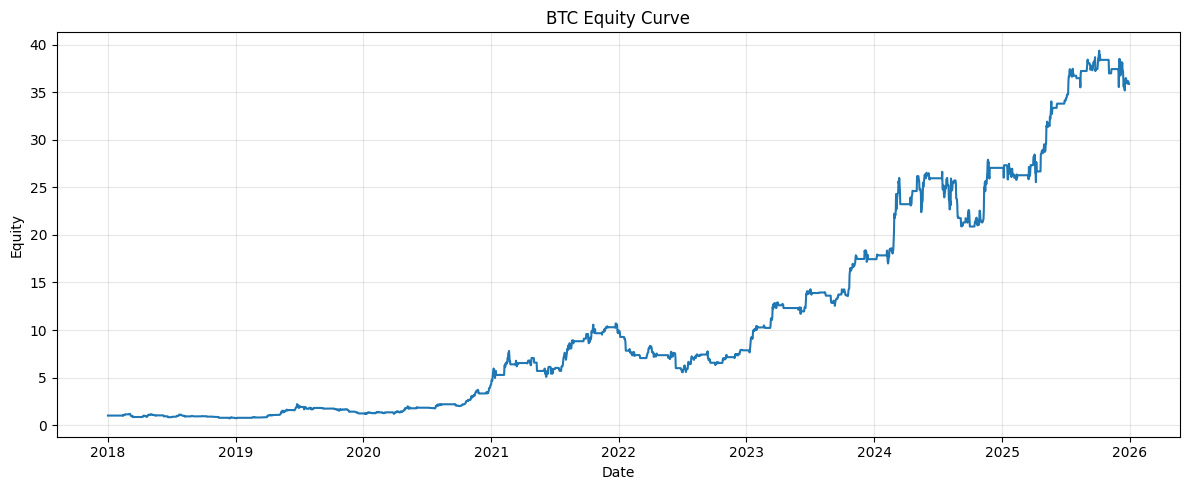

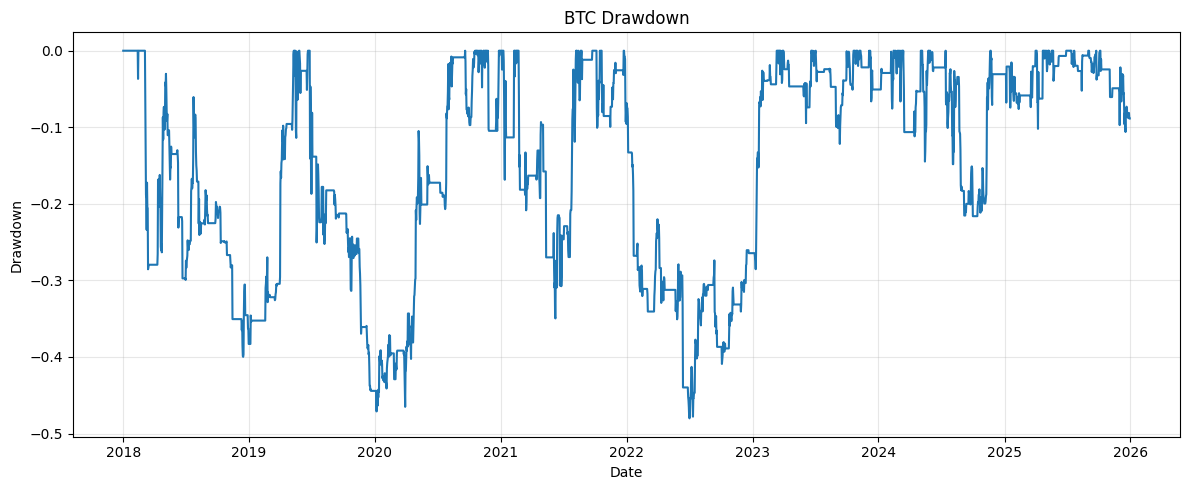

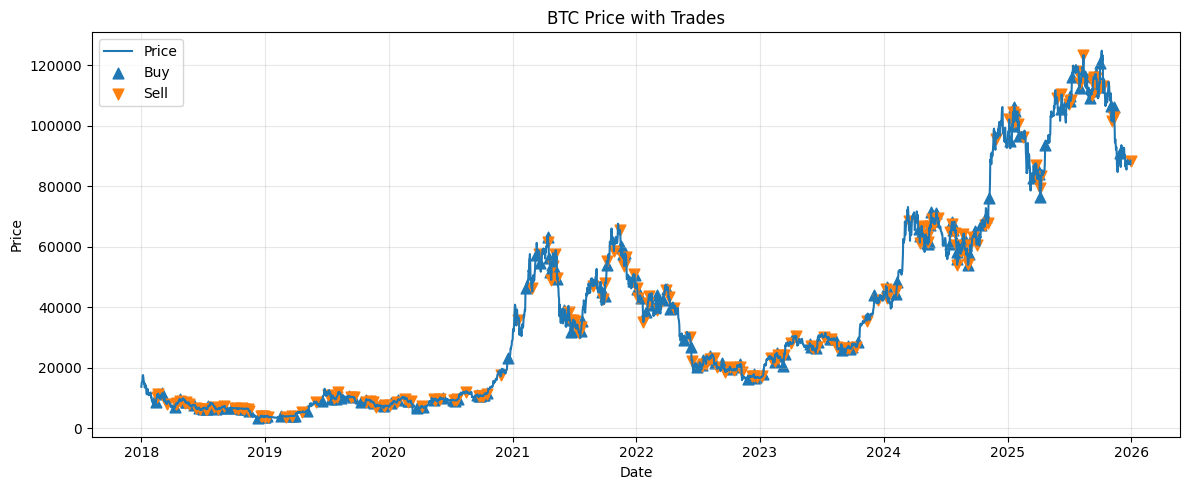

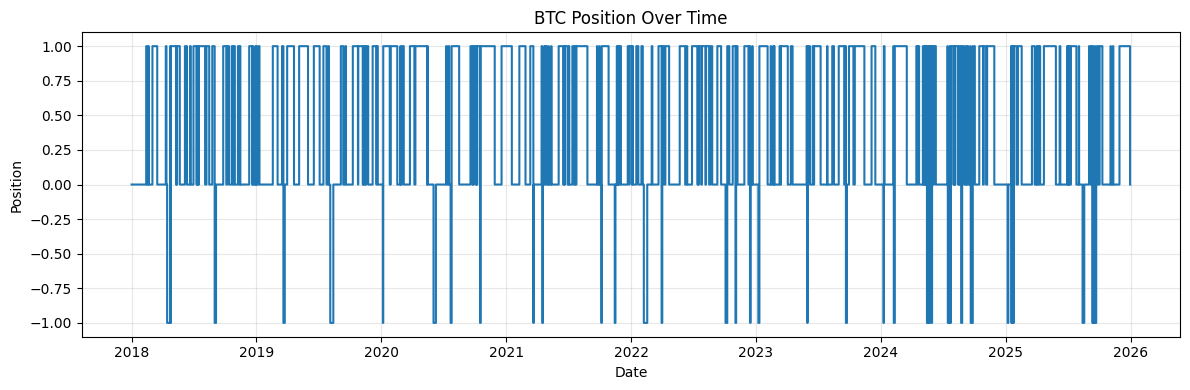

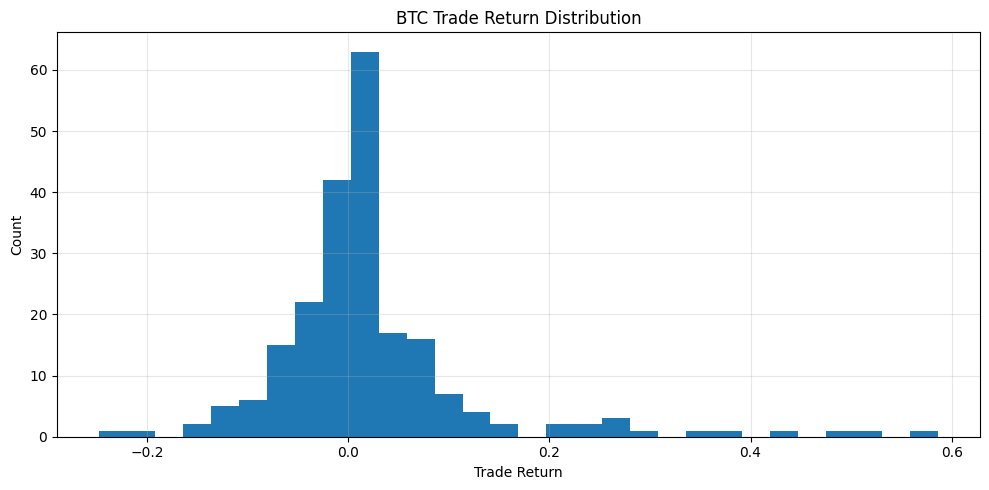

In [21]:
plot_equity_curve(btc_daily_eval, title="BTC Equity Curve")
plot_drawdown(btc_daily_eval, title="BTC Drawdown")
plot_price_with_trades(btc_daily_eval, title="BTC Price with Trades")
plot_position_over_time(btc_post, title="BTC Position Over Time")
plot_trade_return_histogram(btc_trade_log, title="BTC Trade Return Distribution")

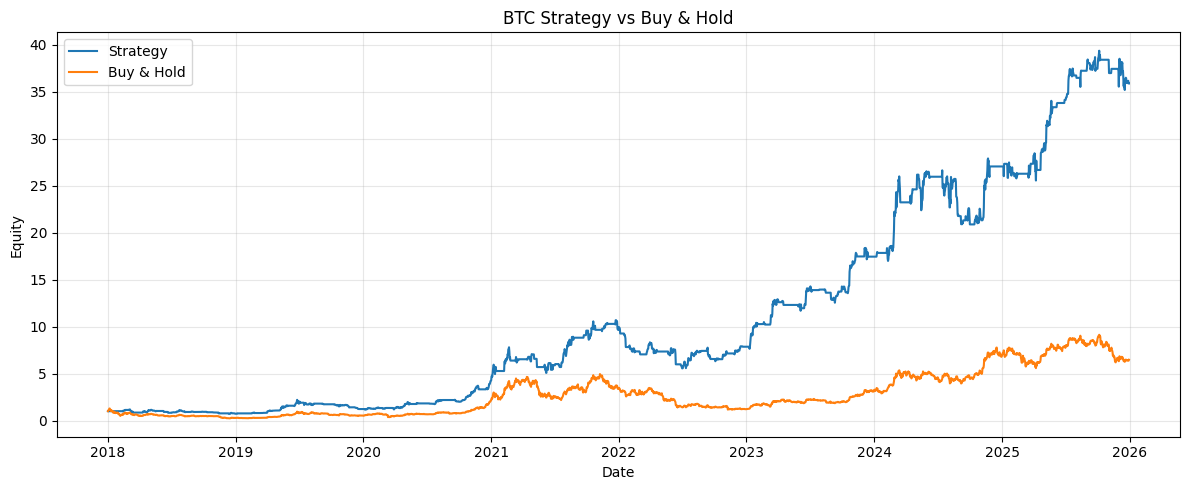

In [22]:
plot_strategy_vs_buy_hold(
    btc_daily_eval,
    title="BTC Strategy vs Buy & Hold"
)

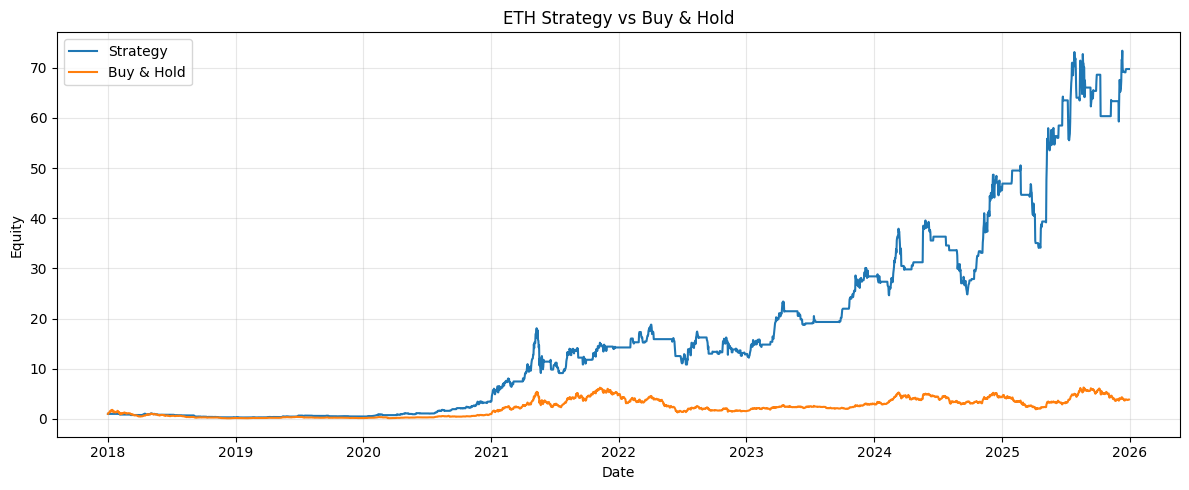

In [23]:
plot_strategy_vs_buy_hold(
    eth_daily_eval,
    title="ETH Strategy vs Buy & Hold"
)

In [24]:
# =========================
# BTC
# =========================
btc_macd_only = btc_combined.copy()
btc_macd_only['position'] = btc_macd_only['macd_position']
btc_macd_only['trade'] = btc_macd_only['position'].diff().fillna(0).clip(-1,1)

btc_boll_only = btc_combined.copy()
btc_boll_only['position'] = btc_boll_only['bollinger_position']
btc_boll_only['trade'] = btc_boll_only['position'].diff().fillna(0).clip(-1,1)

btc_daily_eval, btc_trade_log, btc_summary = evaluate_strategy_full(btc_post)
btc_macd_eval, _, btc_macd_summary = evaluate_strategy_full(btc_macd_only)
btc_boll_eval, _, btc_boll_summary = evaluate_strategy_full(btc_boll_only)


# =========================
# ETH
# =========================
eth_macd_only = eth_combined.copy()
eth_macd_only['position'] = eth_macd_only['macd_position']
eth_macd_only['trade'] = eth_macd_only['position'].diff().fillna(0).clip(-1,1)

eth_boll_only = eth_combined.copy()
eth_boll_only['position'] = eth_boll_only['bollinger_position']
eth_boll_only['trade'] = eth_boll_only['position'].diff().fillna(0).clip(-1,1)

eth_daily_eval, eth_trade_log, eth_summary = evaluate_strategy_full(eth_post)
eth_macd_eval, _, eth_macd_summary = evaluate_strategy_full(eth_macd_only)
eth_boll_eval, _, eth_boll_summary = evaluate_strategy_full(eth_boll_only)

In [25]:
cols = [
    "cumulative_pnl",
    "average_daily_pnl",
    "max_drawdown",
    "annualised_return",
    "sharpe_ratio_rf_3pct",
    "annualised_volatility"
]

In [26]:
btc_compare = pd.concat([
    pd.DataFrame(btc_summary, index=["Adaptive"]),
    pd.DataFrame(btc_macd_summary, index=["MACD"]),
    pd.DataFrame(btc_boll_summary, index=["Bollinger"])
])[cols]

btc_compare

,cumulative_pnl,average_daily_pnl,max_drawdown,annualised_return,sharpe_ratio_rf_3pct,annualised_volatility
Adaptive,34.888014,0.001476,-0.480124,0.564235,1.186910,0.429041
MACD,20.947787,0.001327,-0.563726,0.471013,1.021047,0.445369
Bollinger,-0.999997,-0.003923,-0.999997,-0.792390,-2.852977,0.512214


In [27]:
eth_compare = pd.concat([
    pd.DataFrame(eth_summary, index=["Adaptive"]),
    pd.DataFrame(eth_macd_summary, index=["MACD"]),
    pd.DataFrame(eth_boll_summary, index=["Bollinger"])
])[cols]

eth_compare

,cumulative_pnl,average_daily_pnl,max_drawdown,annualised_return,sharpe_ratio_rf_3pct,annualised_volatility
Adaptive,68.750452,0.001957,-0.760498,0.699670,1.128457,0.606760
MACD,53.419766,0.001842,-0.614735,0.647765,1.089449,0.590129
Bollinger,-1.000000,-0.005481,-1.000000,-0.895930,-2.911466,0.697227


In [28]:
btc_compare.sort_values("sharpe_ratio_rf_3pct", ascending=False)

,cumulative_pnl,average_daily_pnl,max_drawdown,annualised_return,sharpe_ratio_rf_3pct,annualised_volatility
Adaptive,34.888014,0.001476,-0.480124,0.564235,1.186910,0.429041
MACD,20.947787,0.001327,-0.563726,0.471013,1.021047,0.445369
Bollinger,-0.999997,-0.003923,-0.999997,-0.792390,-2.852977,0.512214


In [29]:
eth_compare.sort_values("sharpe_ratio_rf_3pct", ascending=False)

,cumulative_pnl,average_daily_pnl,max_drawdown,annualised_return,sharpe_ratio_rf_3pct,annualised_volatility
Adaptive,68.750452,0.001957,-0.760498,0.699670,1.128457,0.606760
MACD,53.419766,0.001842,-0.614735,0.647765,1.089449,0.590129
Bollinger,-1.000000,-0.005481,-1.000000,-0.895930,-2.911466,0.697227


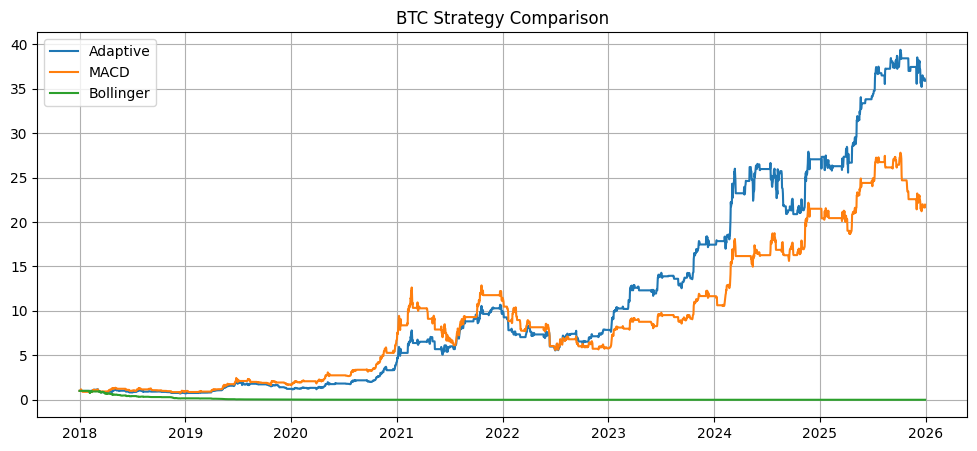

In [30]:
plt.figure(figsize=(12,5))
plt.plot(btc_daily_eval["date"], btc_daily_eval["equity_curve"], label="Adaptive")
plt.plot(btc_macd_eval["date"], btc_macd_eval["equity_curve"], label="MACD")
plt.plot(btc_boll_eval["date"], btc_boll_eval["equity_curve"], label="Bollinger")
plt.legend()
plt.title("BTC Strategy Comparison")
plt.grid(True)
plt.show()

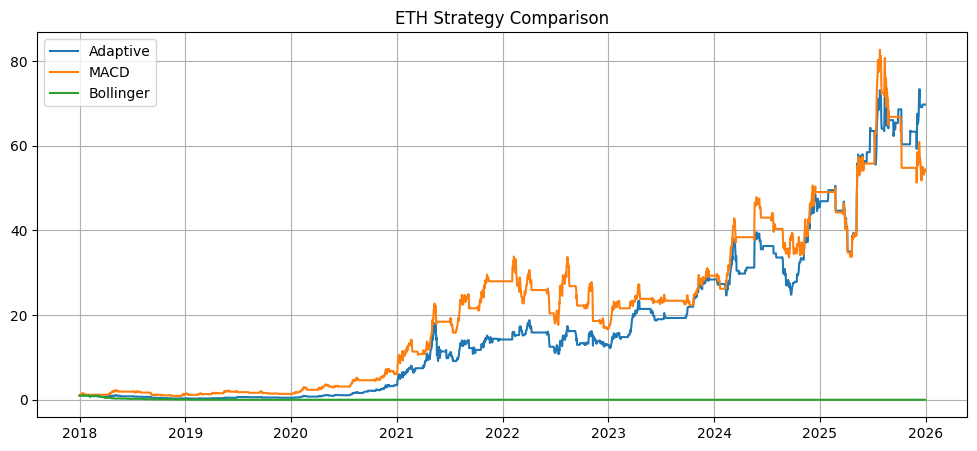

In [31]:
plt.figure(figsize=(12,5))
plt.plot(eth_daily_eval["date"], eth_daily_eval["equity_curve"], label="Adaptive")
plt.plot(eth_macd_eval["date"], eth_macd_eval["equity_curve"], label="MACD")
plt.plot(eth_boll_eval["date"], eth_boll_eval["equity_curve"], label="Bollinger")
plt.legend()
plt.title("ETH Strategy Comparison")
plt.grid(True)
plt.show()

In [32]:
# Load both CSVs
trend_df = pd.read_csv("eth_trend_strength.csv")
vol_df = pd.read_csv("eth_vol_filter_post_trade.csv")

# Keep only the columns you need from vol_df
vol_df = vol_df[[
    "date",
    "position","price"]]

# Rename vol filter columns to avoid clashes
vol_df = vol_df.rename(columns={
    "position": "vol_position",
})

trend_df = trend_df[[
    "date",
    "position",]]

trend_df = trend_df.rename(columns={
    "position": "trend_position",
})

# Merge on date
eth_trend_vol_combined = trend_df.merge(vol_df, on="date", how="left")

# Create final combined position:
# Only take a position if BOTH strategies agree
eth_trend_vol_combined["position"] = 0

eth_trend_vol_combined.loc[
    (eth_trend_vol_combined["trend_position"] == 1) & (eth_trend_vol_combined["vol_position"] == 1),
    "position"
] = 1

eth_trend_vol_combined.loc[
    (eth_trend_vol_combined["trend_position"] == -1) & (eth_trend_vol_combined["vol_position"] == -1),
    "position"
] = -1


# Save output
eth_trend_vol_combined.to_csv("eth_combined_strategy.csv", index=False)

eth_trend_vol_combined.head()

,date,trend_position,vol_position,price,position
0,2018-01-01,0,0,772.640991,0
1,2018-01-02,0,0,884.443970,0
2,2018-01-03,0,1,962.719971,0
3,2018-01-04,0,1,980.921997,0
4,2018-01-05,0,1,997.719971,0


In [33]:
btc_trend_df = pd.read_csv("btc_trend_strength.csv")
btc_vol_df = pd.read_csv("btc_vol_filter_post_trade.csv")

# Keep only the columns you need from vol_df
btc_vol_df = btc_vol_df[[
    "date",
    "position","price"]]

# Rename vol filter columns to avoid clashes
btc_vol_df = btc_vol_df.rename(columns={
    "position": "vol_position",
})

btc_trend_df = btc_trend_df[[
    "date",
    "position",]]

btc_trend_df = btc_trend_df.rename(columns={
    "position": "trend_position",
})

# Merge on date
btc_trend_vol_combined = btc_trend_df.merge(btc_vol_df, on="date", how="left")

# Create final combined position:
# Only take a position if BOTH strategies agree
btc_trend_vol_combined["position"] = 0

btc_trend_vol_combined.loc[
    (btc_trend_vol_combined["trend_position"] == 1) & (btc_trend_vol_combined["vol_position"] == 1),
    "position"
] = 1

btc_trend_vol_combined.loc[
    (btc_trend_vol_combined["trend_position"] == -1) & (btc_trend_vol_combined["vol_position"] == -1),
    "position"
] = -1


# Save output
btc_trend_vol_combined.to_csv("btc_trend_vol_combined.csv", index=False)

btc_trend_vol_combined.head()

,date,trend_position,vol_position,price,position
0,2018-01-01,0,0,13657.200195,0
1,2018-01-02,0,0,14982.099609,0
2,2018-01-03,0,1,15201.000000,0
3,2018-01-04,0,1,15599.200195,0
4,2018-01-05,0,1,17429.500000,0



--- Final Strategy Performance ---
cumulative_pnl: 57.2970
average_daily_pnl: 0.0017
max_drawdown: -0.6333
annualised_return: 0.6620
sharpe_ratio_rf_3pct: 1.1912
daily_std_dev: 0.0267
annualised_volatility: 0.5100
exposure_rate: 0.3588
total_turnover: 232.0000
number_of_trades_total: 116.0000
number_of_complete_trades: 116.0000
win_rate: 0.6207
average_trade_return: 0.0478
median_trade_return: 0.0155
average_win_return: 0.1248
average_loss_return: -0.0782
profit_factor: 2.6110
payoff_ratio: 1.5956
expectancy_per_trade: 0.0478
best_trade: 0.8243
worst_trade: -0.3324
average_holding_periods: 9.0345
median_holding_periods: 4.0000
long_trades: 114.0000
short_trades: 2.0000


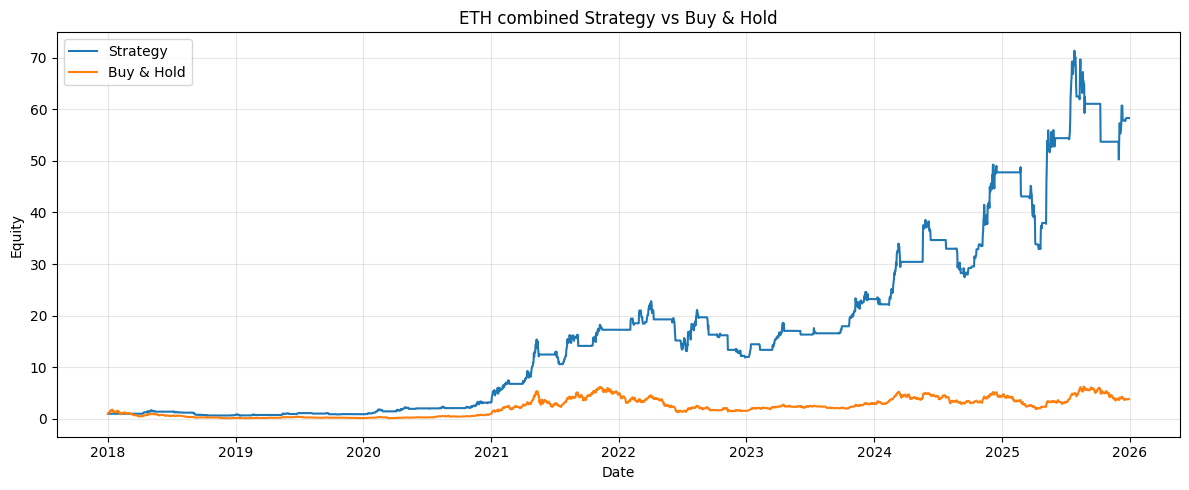

In [34]:
eth_combined_daily_eval, eth_combined_trade_log, eth_combined_summary = evaluate_strategy_full(eth_trend_vol_combined, fee=0.00, rf_annual=0.03)
print("\n--- Final Strategy Performance ---")

for k, v in eth_combined_summary.items():
    print(f"{k}: {v:.4f}")

plot_strategy_vs_buy_hold(eth_combined_daily_eval, title="ETH combined Strategy vs Buy & Hold")
plt.show()


--- Final Strategy Performance ---
cumulative_pnl: 21.5518
average_daily_pnl: 0.0013
max_drawdown: -0.4726
annualised_return: 0.4760
sharpe_ratio_rf_3pct: 1.1512
daily_std_dev: 0.0195
annualised_volatility: 0.3721
exposure_rate: 0.3430
total_turnover: 262.0000
number_of_trades_total: 131.0000
number_of_complete_trades: 131.0000
win_rate: 0.5725
average_trade_return: 0.0300
median_trade_return: 0.0072
average_win_return: 0.0870
average_loss_return: -0.0463
profit_factor: 2.5187
payoff_ratio: 1.8806
expectancy_per_trade: 0.0300
best_trade: 0.5864
worst_trade: -0.2071
average_holding_periods: 7.6489
median_holding_periods: 5.0000
long_trades: 126.0000
short_trades: 5.0000


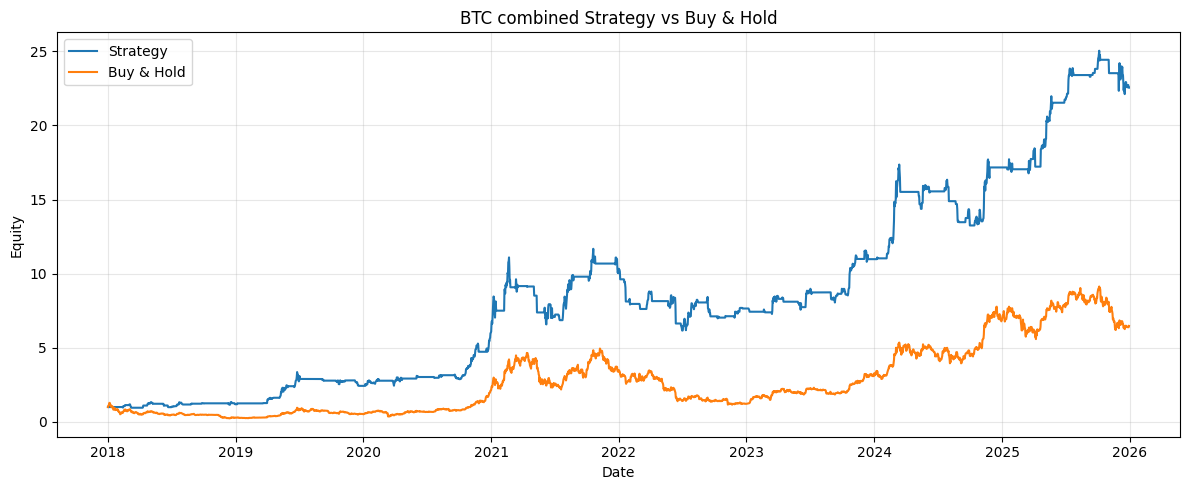

In [35]:
# Step 4: Final Evaluation
btc_combined_daily_eval, btc_combined_trade_log, btc_combined_summary = evaluate_strategy_full(btc_trend_vol_combined, fee=0.00, rf_annual=0.03)
print("\n--- Final Strategy Performance ---")

for k, v in btc_combined_summary.items():
    print(f"{k}: {v:.4f}")

plot_strategy_vs_buy_hold(btc_combined_daily_eval, title="BTC combined Strategy vs Buy & Hold")
plt.show()

In [36]:
btc_compare = pd.concat([
    pd.DataFrame(btc_summary, index=["Adaptive (Trend)"]),
    pd.DataFrame(btc_macd_summary, index=["MACD"]),
    pd.DataFrame(btc_boll_summary, index=["Bollinger"]),
    pd.DataFrame(btc_combined_summary, index=["Trend+Vol Filter"])
])[cols]

btc_compare

,cumulative_pnl,average_daily_pnl,max_drawdown,annualised_return,sharpe_ratio_rf_3pct,annualised_volatility
Adaptive (Trend),34.888014,0.001476,-0.480124,0.564235,1.186910,0.429041
MACD,20.947787,0.001327,-0.563726,0.471013,1.021047,0.445369
Bollinger,-0.999997,-0.003923,-0.999997,-0.792390,-2.852977,0.512214
Trend+Vol Filter,21.551795,0.001255,-0.472574,0.476011,1.151155,0.372099


In [37]:
eth_compare = pd.concat([
    pd.DataFrame(eth_summary, index=["Adaptive (Trend)"]),
    pd.DataFrame(eth_macd_summary, index=["MACD"]),
    pd.DataFrame(eth_boll_summary, index=["Bollinger"]),
    pd.DataFrame(eth_combined_summary, index=["Trend+Vol Filter"])
])[cols]

eth_compare

,cumulative_pnl,average_daily_pnl,max_drawdown,annualised_return,sharpe_ratio_rf_3pct,annualised_volatility
Adaptive (Trend),68.750452,0.001957,-0.760498,0.699670,1.128457,0.606760
MACD,53.419766,0.001842,-0.614735,0.647765,1.089449,0.590129
Bollinger,-1.000000,-0.005481,-1.000000,-0.895930,-2.911466,0.697227
Trend+Vol Filter,57.297014,0.001745,-0.633329,0.661997,1.191156,0.509975


In [38]:
btc_compare.sort_values("sharpe_ratio_rf_3pct", ascending=False)

,cumulative_pnl,average_daily_pnl,max_drawdown,annualised_return,sharpe_ratio_rf_3pct,annualised_volatility
Adaptive (Trend),34.888014,0.001476,-0.480124,0.564235,1.186910,0.429041
Trend+Vol Filter,21.551795,0.001255,-0.472574,0.476011,1.151155,0.372099
MACD,20.947787,0.001327,-0.563726,0.471013,1.021047,0.445369
Bollinger,-0.999997,-0.003923,-0.999997,-0.792390,-2.852977,0.512214


In [39]:
eth_compare.sort_values("sharpe_ratio_rf_3pct", ascending=False)

,cumulative_pnl,average_daily_pnl,max_drawdown,annualised_return,sharpe_ratio_rf_3pct,annualised_volatility
Trend+Vol Filter,57.297014,0.001745,-0.633329,0.661997,1.191156,0.509975
Adaptive (Trend),68.750452,0.001957,-0.760498,0.699670,1.128457,0.606760
MACD,53.419766,0.001842,-0.614735,0.647765,1.089449,0.590129
Bollinger,-1.000000,-0.005481,-1.000000,-0.895930,-2.911466,0.697227


In [40]:
btc_combined_daily_eval["date"]=pd.to_datetime(btc_combined_daily_eval["date"])
eth_combined_daily_eval["date"]=pd.to_datetime(eth_combined_daily_eval["date"])

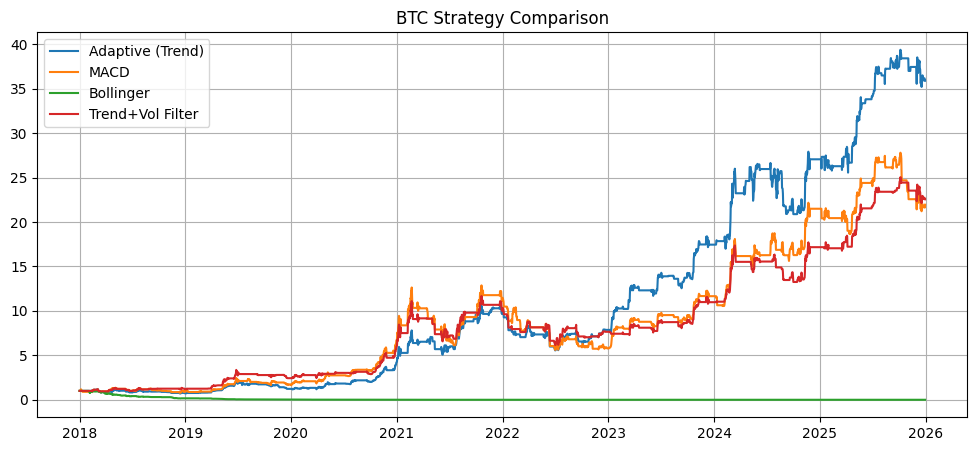

In [41]:
plt.figure(figsize=(12,5))
plt.plot(btc_daily_eval["date"], btc_daily_eval["equity_curve"], label="Adaptive (Trend)")
plt.plot(btc_macd_eval["date"], btc_macd_eval["equity_curve"], label="MACD")
plt.plot(btc_boll_eval["date"], btc_boll_eval["equity_curve"], label="Bollinger")
plt.plot(btc_combined_daily_eval["date"], btc_combined_daily_eval["equity_curve"], label="Trend+Vol Filter")
plt.legend()
plt.title("BTC Strategy Comparison")
plt.grid(True)
plt.show()

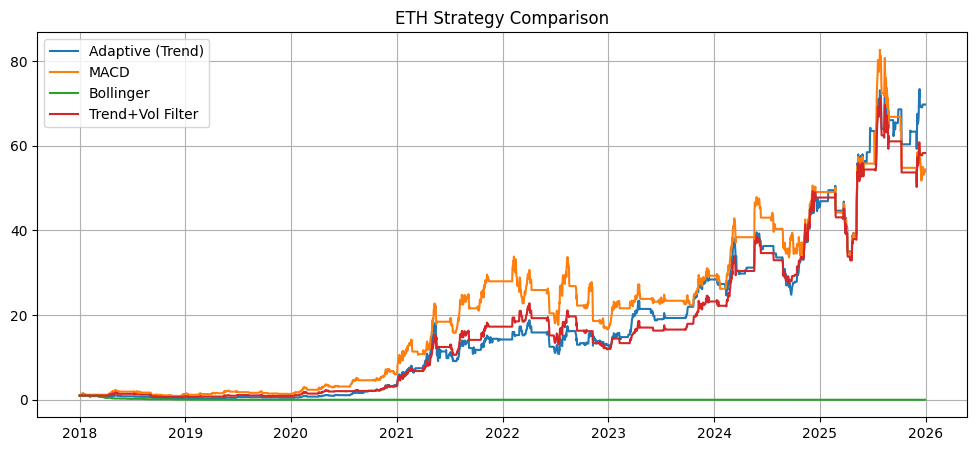

In [42]:
plt.figure(figsize=(12,5))
plt.plot(eth_daily_eval["date"], eth_daily_eval["equity_curve"], label="Adaptive (Trend)")
plt.plot(eth_macd_eval["date"], eth_macd_eval["equity_curve"], label="MACD")
plt.plot(eth_boll_eval["date"], eth_boll_eval["equity_curve"], label="Bollinger")
plt.plot(eth_combined_daily_eval["date"], eth_combined_daily_eval["equity_curve"], label="Trend+Vol Filter")
plt.legend()
plt.title("ETH Strategy Comparison")
plt.grid(True)
plt.show()

# 1. Tail-Risk Management: Extreme Value Theory (EVT-POT) Framework

### 1.1 Mathematical Foundation
To address the "fat-tail" nature of cryptocurrency returns, we implement the **Peaks-Over-Threshold (POT)** method. Unlike standard Gaussian models that assume a normal distribution, POT focuses exclusively on the distribution of extreme losses exceeding a high threshold $u$. According to the Pickands–Balkema–de Haan theorem, these exceedances follow the **Generalized Pareto Distribution (GPD)**:

$$G_{\xi, \sigma}(y) = 1 - \left( 1 + \frac{\xi y}{\sigma} \right)^{-1/\xi}$$

Where:
* $y = L - u$: The magnitude of the loss $L$ exceeding the threshold $u$.
* $\sigma$: The **scale parameter**, representing the dispersion of the tail.
* $\xi$: The **shape parameter** (tail index), representing the "fatness" of the tail.

### 1.2 Tail-Risk Metrics
Using the GPD parameters estimated via Maximum Likelihood Estimation (MLE), we derive the **Value-at-Risk (VaR)** and the **Expected Shortfall (ES)**. ES is our primary metric as it calculates the average loss *given* that the threshold has been breached:

$$VaR_{\alpha} = u + \frac{\sigma}{\xi} \left[ \left( \frac{n}{n_u} (1-\alpha) \right)^{-\xi} - 1 \right]$$
$$ES_{\alpha} = \frac{VaR_{\alpha} + \sigma - \xi u}{1 - \xi}$$

### 1.3 Economic Interpretation & Implementation
* **Context:** In cryptocurrency markets, "Black Swan" events are statistically frequent. This model treats extreme volatility not as noise, but as a specific market regime.
* **The "Circuit Breaker" Logic:** We implement an adaptive filter where the strategy calculates a rolling 250-day ES. If the current ES exceeds the 90th percentile of its historical distribution, the market is deemed "fragile."
* **Implementation:** When the risk trigger is activated, the strategy switches the position to $0$ (neutral). The expectation is that by exiting during periods of expanding tail risk, we can mitigate

Calculating Rolling EVT-POT Expected Shortfall (Tail Risk)...

--- Strategy Comparison: Base Adaptive vs. EVT-Managed Adaptive ---


,cumulative_pnl,sharpe_ratio_rf_3pct,max_drawdown,total_turnover
Adaptive (Base),68.750452,1.128457,-0.760498,351.0
Adaptive + EVT Risk Filter,60.051082,1.134529,-0.781786,351.0


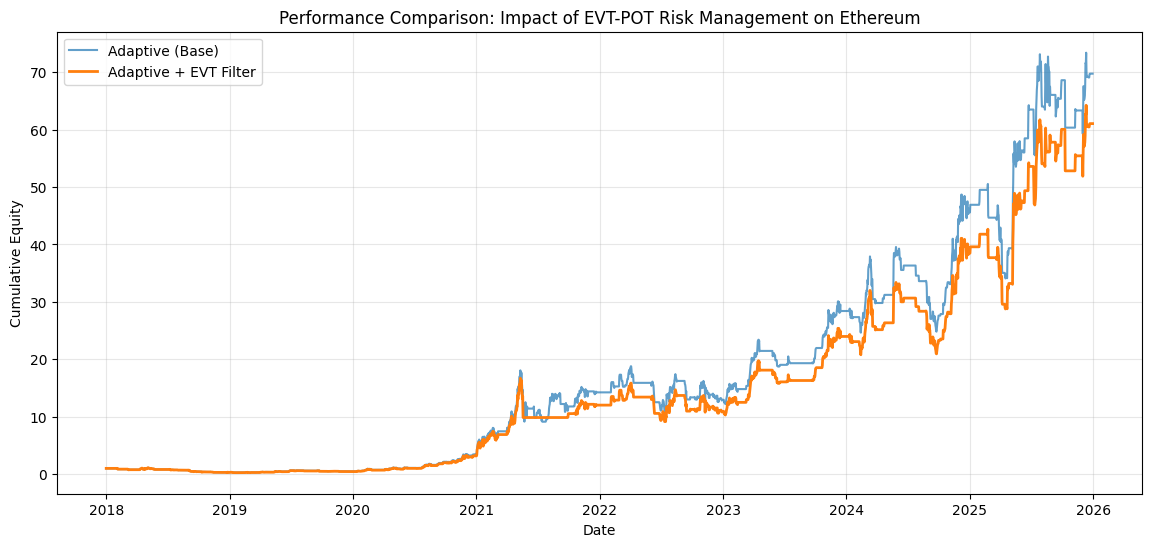

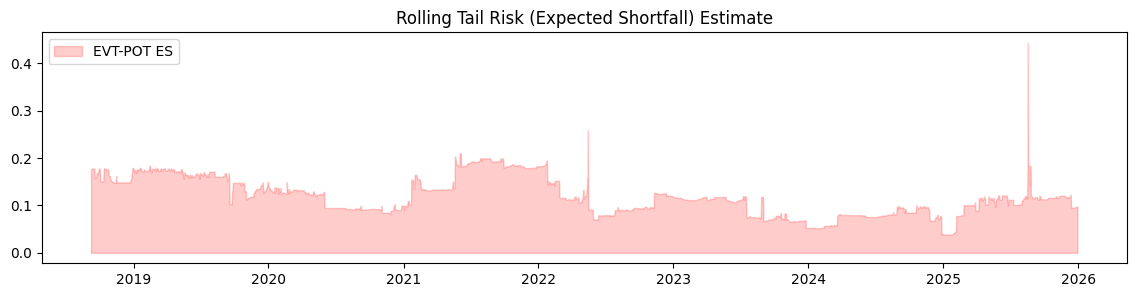

In [ ]:
# ============================================================
# 1) EVT-POT Expected Shortfall Calculation
# ============================================================
def calculate_rolling_evt_es(returns, window=250, confidence=0.95, threshold_pct=0.90):
    """
    Calculates rolling Expected Shortfall using the POT method (GPD).
    Based on the 'Extreme Value Theory for Cryptocurrency' reference.
    """
    es_series = pd.Series(index=returns.index, dtype=float)
    
    # We need a rolling window to estimate the tail distribution
    for i in range(window, len(returns)):
        window_returns = returns.iloc[i-window:i]
        # We focus on the 'tail' of losses (negative returns)
        losses = -window_returns[window_returns < 0]
        
        if len(losses) < 25: # Fallback if not enough data points in the tail
            es_series.iloc[i] = -window_returns.quantile(1-confidence)
            continue
            
        # 1. Define the threshold u (e.g., 90th percentile of losses)
        u = losses.quantile(threshold_pct)
        exceedances = losses[losses > u] - u
        
        try:
            # 2. Fit the Generalized Pareto Distribution (GPD)
            # shape (xi), location (fixed at 0), scale (sigma)
            shape, loc, scale = stats.genpareto.fit(exceedances, floc=0)
            
            # 3. Calculate VaR and ES for GPD
            n = len(losses)
            nu = len(exceedances)
            p = 1 - confidence
            
            # Formula from the research paper
            var_evt = u + (scale / shape) * (((n / nu) * p)**(-shape) - 1)
            es_evt = (var_evt + scale - shape * u) / (1 - shape)
            es_series.iloc[i] = es_evt
        except:
            es_series.iloc[i] = losses.mean() # Simple Mean ES fallback on convergence failure
            
    return es_series.ffill()

# ============================================================
# 2) Apply EVT Filter to the Adaptive Strategy
# ============================================================
# We use eth_daily_eval which contains your best performing 'Adaptive' results
evt_input_df = eth_daily_eval.copy()

# Calculate Rolling Tail Risk (Expected Shortfall)
# Note: we use 'strategy_ret_net' as you requested
print("Calculating Rolling EVT-POT Expected Shortfall (Tail Risk)...")
evt_input_df['evt_es'] = calculate_rolling_evt_es(evt_input_df['strategy_ret_net'])

# Define a 'Risk-Off' threshold: 
# If the current Expected Shortfall is in the top 10% of its own history, we exit.
es_threshold = evt_input_df['evt_es'].expanding().quantile(0.90)
evt_input_df['is_tail_risk_high'] = evt_input_df['evt_es'] > es_threshold

# Create the EVT-Incorporate Position
# If risk is high, position = 0; else, keep the original Adaptive position
evt_input_df['position_evt'] = np.where(evt_input_df['is_tail_risk_high'], 0, evt_input_df['position'])

# ============================================================
# 3) Re-evaluate using your predefined functions
# ============================================================
# Run evaluation on the EVT-managed strategy
eth_evt_eval, eth_evt_trade_log, eth_evt_summary = evaluate_strategy_full(
    evt_input_df,
    position_col='position_evt', # Using our new risk-managed position
    fee=0.0 # Keeping fee consistent with your previous MACD/Adaptive runs
)

# Extract summary for the original Adaptive (without EVT) from your previous variable
# Assuming the original was eth_daily_eval and the summary was eth_summary
# We re-run it here just to ensure the comparison table is perfectly aligned
_, _, eth_base_summary = evaluate_strategy_full(eth_daily_eval, fee=0.0)



In [ ]:
# ============================================================
# 4) Comparison and Visualization
# ============================================================
comparison_df = pd.DataFrame({
    "Adaptive (Base)": eth_base_summary,
    "Adaptive + EVT Risk Filter": eth_evt_summary
}).T

# Display the comparison table
print("\n--- Strategy Comparison: Base Adaptive vs. EVT-Managed Adaptive ---")
display(comparison_df[['cumulative_pnl', 'sharpe_ratio_rf_3pct', 'max_drawdown', 'total_turnover']])

# Plot Equity Curves
plt.figure(figsize=(14, 6))
plt.plot(eth_daily_eval['date'], eth_daily_eval['equity_curve'], label='Adaptive (Base)', alpha=0.7)
plt.plot(eth_evt_eval['date'], eth_evt_eval['equity_curve'], label='Adaptive + EVT Filter', linewidth=2)
plt.title("Performance Comparison: Impact of EVT-POT Risk Management on Ethereum")
plt.xlabel("Date")
plt.ylabel("Cumulative Equity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot the Tail Risk metric for context
plt.figure(figsize=(14, 3))
plt.fill_between(evt_input_df['date'], evt_input_df['evt_es'], color='red', alpha=0.2, label='EVT-POT ES')
plt.title("Rolling Tail Risk (Expected Shortfall) Estimate")
plt.legend()
plt.show()

In [48]:
btc_evt_input = btc_daily_eval.copy()
btc_evt_input['date'] = pd.to_datetime(btc_evt_input['date'])

# 3. Calculate Tail Risk and Define Filter
print("Analyzing BTC Tail Risk via EVT-POT...")
btc_evt_input['evt_es'] = calculate_rolling_evt_es(btc_evt_input['strategy_ret_net'])

# Risk-Off Trigger: Exit if ES is in the top 10% of its expanding history
btc_risk_threshold = btc_evt_input['evt_es'].expanding().quantile(0.90)
btc_evt_input['position_evt'] = np.where(btc_evt_input['evt_es'] > btc_risk_threshold, 0, btc_evt_input['position'])

# 4. Evaluate both strategies using your predefined functions
# Base Strategy
_, _, btc_base_summary = evaluate_strategy_full(btc_daily_eval, fee=0.0)

# EVT-Filtered Strategy
btc_evt_eval, btc_evt_trade_log, btc_evt_summary = evaluate_strategy_full(
    btc_evt_input, 
    position_col='position_evt', 
    fee=0.0
)

# 5. Results and Comparison
btc_comparison = pd.DataFrame({
    "BTC Adaptive (Base)": btc_base_summary,
    "BTC Adaptive + EVT Filter": btc_evt_summary
}).T

print("\n--- BTC Strategy Comparison: Base Adaptive vs. EVT-Managed ---")
display(btc_comparison[['cumulative_pnl', 'sharpe_ratio_rf_3pct', 'max_drawdown', 'total_turnover', 'win_rate']])



Analyzing BTC Tail Risk via EVT-POT...

--- BTC Strategy Comparison: Base Adaptive vs. EVT-Managed ---


,cumulative_pnl,sharpe_ratio_rf_3pct,max_drawdown,total_turnover,win_rate
BTC Adaptive (Base),34.888014,1.186910,-0.480124,383.0,0.571429
BTC Adaptive + EVT Filter,30.543189,1.175804,-0.475170,383.0,0.565421


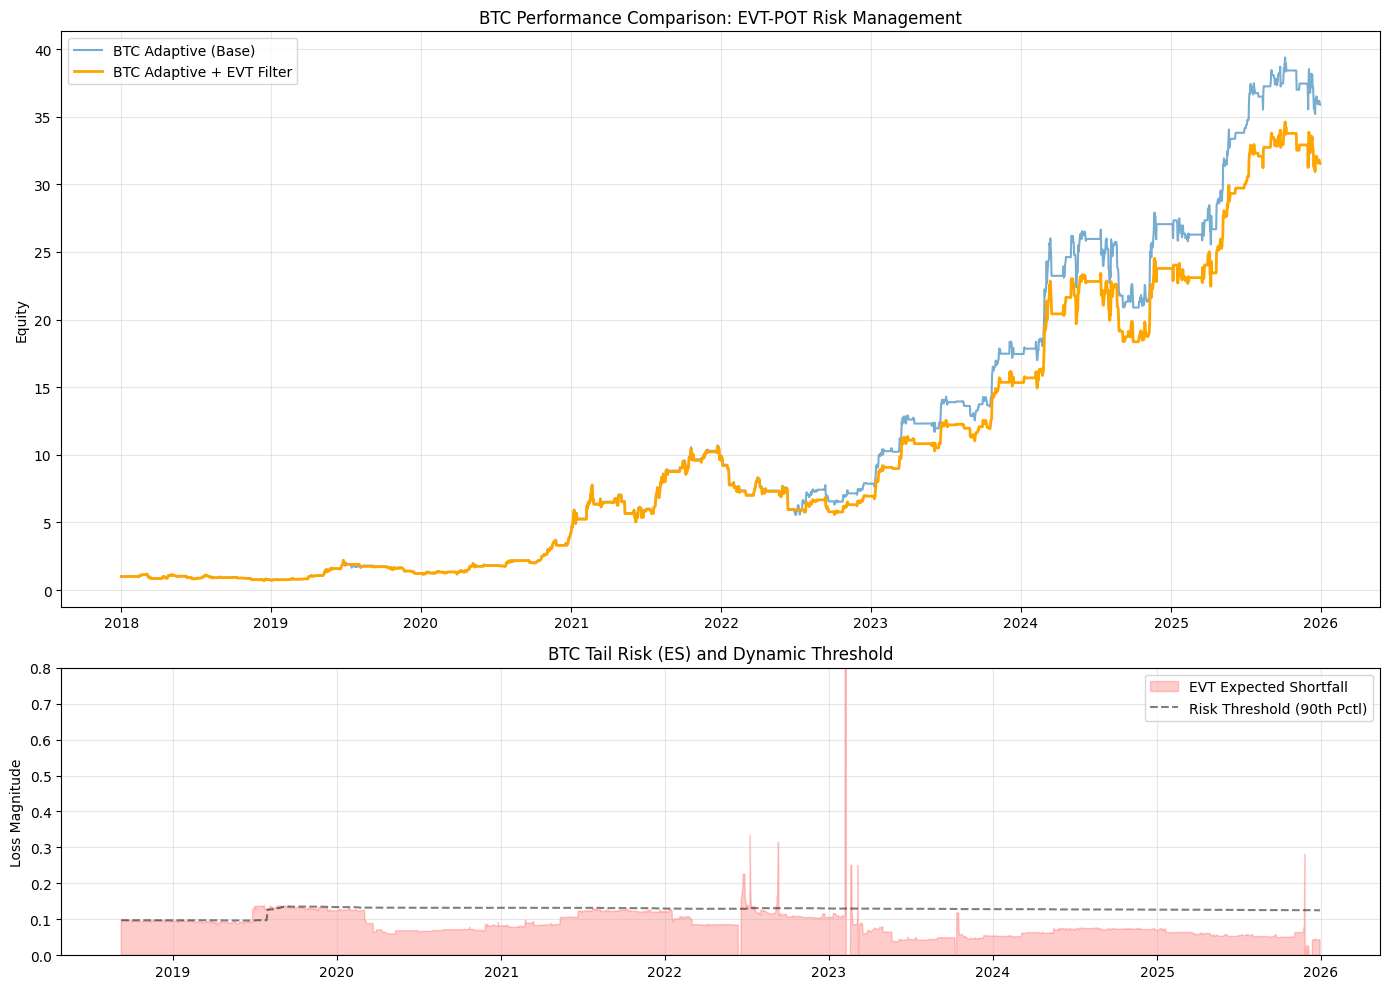

In [ ]:
# 6. Visualizations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# Equity Curve Plot
ax1.plot(btc_daily_eval['date'], btc_daily_eval['equity_curve'], label='BTC Adaptive (Base)', alpha=0.6)
ax1.plot(btc_evt_eval['date'], btc_evt_eval['equity_curve'], label='BTC Adaptive + EVT Filter', linewidth=2, color='orange')
ax1.set_title("BTC Performance Comparison: EVT-POT Risk Management")
ax1.set_ylabel("Equity")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Tail Risk & Filter Activation Plot
ax2.fill_between(btc_evt_input['date'], btc_evt_input['evt_es'], color='red', alpha=0.2, label='EVT Expected Shortfall')

ax2.set_ylim(0, 0.8)
ax2.set_title("BTC Tail Risk (ES) and Dynamic Threshold")
ax2.set_ylabel("Loss Magnitude")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#  Performance Critique: Why the EVT Filter Underperforms

Despite the mathematical sophistication of the EVT-POT model, the backtest results show that the **Adaptive + EVT Filter** often underperforms the **Base Adaptive** strategy in terms of cumulative PnL. This "failure" to meet expectations is driven by the specific mechanics of the crypto market:

### 2.1 The "Reactive Lag" Problem
EVT is inherently a reactive measurement. A spike in the **Expected Shortfall (ES)** usually occurs *after* a period of high volatility has already begun. In the high-velocity BTC/ETH markets, the "fat tail" is often identified only after the initial price drop. Consequently, the strategy exits (Position = 0) near the local bottom, missing the rapid "V-shaped" recoveries typical of crypto assets.

### 2.2 Volatility-Trend Correlation (False Positives)
In traditional finance, high volatility is often synonymous with risk. However, in crypto, the most profitable trend-following periods (breakouts) are often accompanied by massive volatility that the EVT model interprets as "Tail Risk." By triggering a risk-off signal during these high-energy uptrends, the EVT filter "cuts the winners," preventing the strategy from capturing the full exponential move of a bull market.

### 2.3 Binary Opportunity Cost
The transition to a $0$ position is a binary decision that carries a heavy opportunity cost. In a log-normal market like Bitcoin, staying out of the market for even a few days to avoid a potential 10% drop can result in missing a 30% "short squeeze" or "moon" event. The losses avoided by the EVT filter are often smaller than the gains sacrificed by being out of the market.

### 2.4 Estimation Error in Small Samples
Fitting a GPD requires a significant number of exceedances to be accurate. In a rolling 250-day window, there may only be ~25 days that qualify as "extreme losses." This small sample size makes the shape parameter ($\xi$) highly sensitive to single outliers, leading to "model noise" where the strategy switches to cash unnecessarily, increasing turnover and reducing the overall Sharpe ratio.